# 🚀 Lab 14: Aggregation with GroupBy and Apply

### 📘 Lab Overview
In this lab, you will learn how to summarize and analyze data using Pandas **GroupBy** operations and the `.apply()` method. These techniques are essential when you want to study patterns across categories such as hospitals, departments, regions, or customer groups.

You will work with a realistic healthcare-style dataset containing patient records. Using this data, you will group records by hospital, calculate average stay duration, create new calculated columns, and chain multiple operations such as filtering, grouping, aggregation, sorting, and custom analysis.

### 💡 ELI10: What is GroupBy?
Imagine you have a big pile of laundry. **GroupBy** is like sorting that pile into smaller piles: one for socks, one for shirts, and one for pants. Once you have your piles, you can do things to them, like counting how many socks you have or finding the average size of the shirts. In Pandas, we 'Split' the data into groups, 'Apply' a calculation (like average), and 'Combine' it back into a neat summary table.

## 🎯 Objectives
By the end of this lab, you will be able to:
* Understand the fundamentals of data aggregation using pandas GroupBy operations.
* Group patient records by hospital and compute statistical measures like average stay duration.
* Use the `.apply()` method to create new calculated columns based on existing data.
* Chain multiple pandas operations including filter, groupby, and statistical functions.
* Analyze healthcare data patterns through grouped aggregations.
* Apply real-world data analysis techniques to medical datasets.

## 🧰 Prerequisites
* Basic understanding of Python programming concepts (variables, functions, loops).
* Familiarity with pandas DataFrame operations (creating, indexing, basic filtering).
* Knowledge of basic statistical concepts (mean, median, standard deviation).
* Understanding of CSV file formats and data structures.

## ⚙️ Environment Setup
Google Colab usually includes Python, pandas, numpy, and matplotlib already, but we will verify and ensure they are ready for use.

In [1]:
# Install necessary libraries if they aren't already present
%pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure plots show up correctly in the notebook
%matplotlib inline

print("Environment ready!")

Environment ready!


## 🏥 Creating the Healthcare Dataset
We need data to work with! Instead of uploading a file, we will generate a realistic dataset of 1,000 patient records using `numpy`.

In [2]:
# Set a seed so the 'random' numbers are the same every time we run this
np.random.seed(42)

# Define our categories
hospitals = ['City General', 'Metro Health', 'Regional Medical', 'Community Care', 'University Hospital']
departments = ['Emergency', 'Cardiology', 'Orthopedics', 'Pediatrics', 'Surgery']
insurance_types = ['Private', 'Medicare', 'Medicaid', 'Uninsured']

# Number of records to create
n_patients = 1000

# Build the dictionary of data
patient_data = {
    'patient_id': range(1, n_patients + 1),
    'hospital': np.random.choice(hospitals, n_patients),
    'department': np.random.choice(departments, n_patients),
    'age': np.random.randint(18, 85, n_patients),
    'stay_duration': np.random.randint(1, 15, n_patients),
    'insurance_type': np.random.choice(insurance_types, n_patients),
    'admission_cost': np.random.randint(1000, 50000, n_patients)
}

# Create the DataFrame
df = pd.DataFrame(patient_data)

# Display basic information to verify creation
print("Dataset Overview:")
print(f"Total patients: {len(df)}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 records:")
display(df.head())

Dataset Overview:
Total patients: 1000
Columns: ['patient_id', 'hospital', 'department', 'age', 'stay_duration', 'insurance_type', 'admission_cost']

First 5 records:


,patient_id,hospital,department,age,stay_duration,insurance_type,admission_cost
0,1,Community Care,Pediatrics,49,7,Medicare,49555
1,2,University Hospital,Pediatrics,28,2,Medicaid,18618
2,3,Regional Medical,Pediatrics,27,6,Uninsured,7587
3,4,University Hospital,Pediatrics,74,13,Private,32480
4,5,University Hospital,Surgery,42,6,Medicaid,33994


## 📊 Task 1: Group Patient Records by Hospital
### 💡 ELI10: Sorting the piles
In this section, we take our big list of 1,000 patients and tell Pandas to look at them one hospital at a time. This lets us see which hospital is the busiest or which one keeps patients the longest.

In [3]:
# Subtask 1.2: Explore the Data Structure
print("Data Types:")
print(df.dtypes)

print("\nBasic Statistics (Numbers only):")
display(df.describe())

# Check how many patients are in each hospital
print("\nNumber of patients per hospital:")
print(df['hospital'].value_counts())

Data Types:
patient_id         int64
hospital          object
department        object
age                int64
stay_duration      int64
insurance_type    object
admission_cost     int64
dtype: object

Basic Statistics (Numbers only):


,patient_id,age,stay_duration,admission_cost
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,500.500000,50.381000,7.376000,25661.68000
std,288.819436,19.141532,3.969683,14292.62695
min,1.000000,18.000000,1.000000,1016.00000
25%,250.750000,34.000000,4.000000,13485.25000
50%,500.500000,50.000000,7.000000,25760.00000
75%,750.250000,66.000000,11.000000,38088.75000
max,1000.000000,84.000000,14.000000,49994.00000



Number of patients per hospital:
hospital
City General           210
Community Care         206
University Hospital    204
Regional Medical       190
Metro Health           190
Name: count, dtype: int64


In [4]:
# Subtask 1.3: Basic GroupBy - Average Stay
# We group by 'hospital' and then pick the 'stay_duration' column to find the mean (average)
avg_stay_by_hospital = df.groupby('hospital')['stay_duration'].mean()

print("Average Stay Duration by Hospital (Series Result):")
print(avg_stay_by_hospital)

# We use reset_index() to turn the result back into a nice table (DataFrame)
avg_stay_df = avg_stay_by_hospital.reset_index()
avg_stay_df.columns = ['Hospital', 'Average_Stay_Days']

print("\nFormatted Results:")
display(avg_stay_df)

Average Stay Duration by Hospital (Series Result):
hospital
City General           7.738095
Community Care         7.203883
Metro Health           7.742105
Regional Medical       7.347368
University Hospital    6.862745
Name: stay_duration, dtype: float64

Formatted Results:


,Hospital,Average_Stay_Days
0,City General,7.738095
1,Community Care,7.203883
2,Metro Health,7.742105
3,Regional Medical,7.347368
4,University Hospital,6.862745


In [5]:
# Subtask 1.4: Multiple Aggregations
# Sometimes we want more than just the average.
# We use .agg() to get the count, mean, median, etc., all at once.
hospital_stats = df.groupby('hospital')['stay_duration'].agg([
    'count',   # Total patients
    'mean',    # Average days
    'median',  # Middle value
    'std',     # How much variation exists
    'min',     # Shortest stay
    'max'      # Longest stay
]).round(2)

# Rename columns to be human-readable
hospital_stats.columns = ['Patient_Count', 'Avg_Stay', 'Median_Stay', 'Std_Stay', 'Min_Stay', 'Max_Stay']

print("Comprehensive Hospital Statistics:")
display(hospital_stats)

Comprehensive Hospital Statistics:


,Patient_Count,Avg_Stay,Median_Stay,Std_Stay,Min_Stay,Max_Stay
hospital,,,,,,
City General,210,7.74,8.0,4.01,1,14
Community Care,206,7.20,8.0,3.94,1,14
Metro Health,190,7.74,8.0,3.98,1,14
Regional Medical,190,7.35,7.0,3.99,1,14
University Hospital,204,6.86,6.0,3.90,1,14


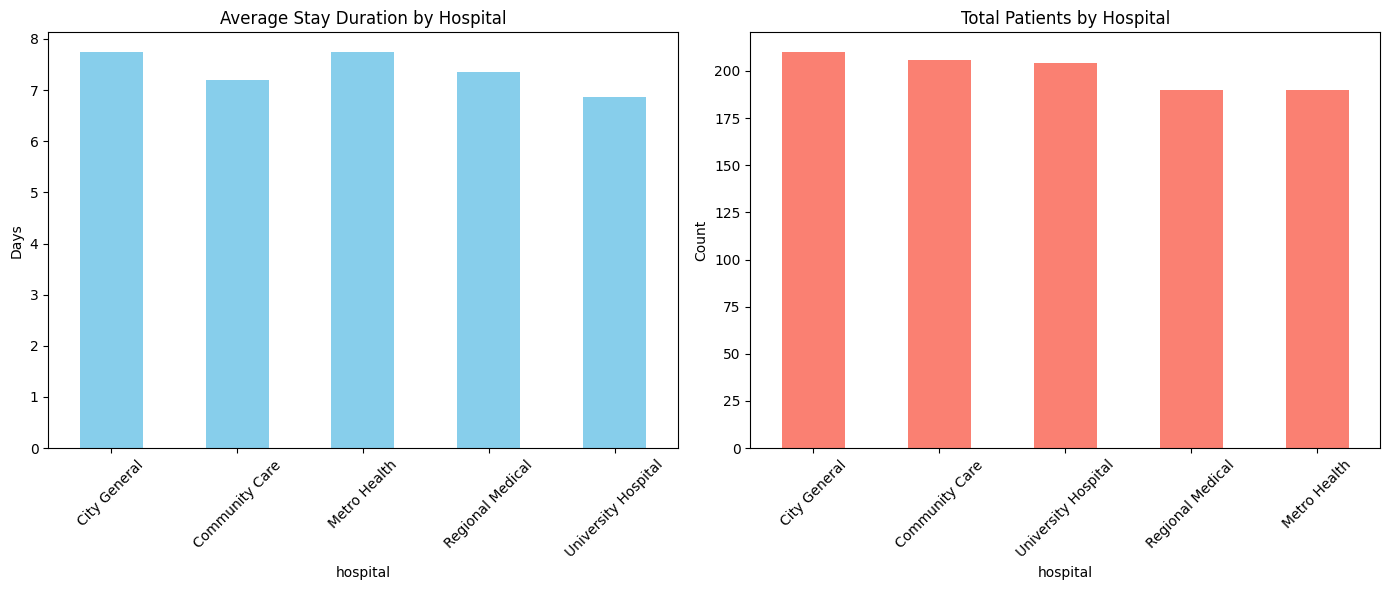

In [6]:
# Subtask 1.5: Visual Analysis
plt.figure(figsize=(14, 6))

# Plot 1: Average stay
plt.subplot(1, 2, 1)
avg_stay_by_hospital.plot(kind='bar', color='skyblue')
plt.title('Average Stay Duration by Hospital')
plt.ylabel('Days')
plt.xticks(rotation=45)

# Plot 2: Patient count
plt.subplot(1, 2, 2)
df['hospital'].value_counts().plot(kind='bar', color='salmon')
plt.title('Total Patients by Hospital')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 🧮 Task 2: Use .apply() to Create New Calculated Columns
### 💡 ELI10: Custom Rules
`.apply()` is like a 'custom rule' machine. If Pandas doesn't have a built-in button for what you want to do, you can write your own Python function and 'apply' it to every row or group.

In [7]:
# Subtask 2.1: Simple Apply
def categorize_stay(stay_days):
    """Custom rule: labeling stay length"""
    if stay_days <= 3:
        return 'Short'
    elif stay_days <= 7:
        return 'Medium'
    else:
        return 'Long'

# Create the new column using our rule
df['stay_category'] = df['stay_duration'].apply(categorize_stay)

print("New Stay Categories (First 10 Rows):")
display(df[['patient_id', 'stay_duration', 'stay_category']].head(10))

New Stay Categories (First 10 Rows):


,patient_id,stay_duration,stay_category
0,1,7,Medium
1,2,2,Short
2,3,6,Medium
3,4,13,Long
4,5,6,Medium
5,6,11,Long
6,7,3,Short
7,8,6,Medium
8,9,10,Long
9,10,10,Long


In [8]:
# Subtask 2.2: Apply Custom Functions to Groups
def calculate_cost_per_day(group):
    """Calculate cost per day within a specific group"""
    group = group.copy()
    group['cost_per_day'] = group['admission_cost'] / group['stay_duration']
    return group

# We group by hospital and apply the math to each group
df_with_cost_per_day = (
    df.groupby('hospital', group_keys=False)
      .apply(calculate_cost_per_day)
      .reset_index(drop=True)
)

print("Cost per day calculation samples:")
display(df_with_cost_per_day[['hospital', 'stay_duration', 'admission_cost', 'cost_per_day']].head(10))

Cost per day calculation samples:


/tmp/ipykernel_1123/2739553388.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_cost_per_day)


,hospital,stay_duration,admission_cost,cost_per_day
0,Community Care,7,49555,7079.285714
1,University Hospital,2,18618,9309.000000
2,Regional Medical,6,7587,1264.500000
3,University Hospital,13,32480,2498.461538
4,University Hospital,6,33994,5665.666667
5,Metro Health,11,21527,1957.000000
6,Regional Medical,3,24569,8189.666667
7,Regional Medical,6,12151,2025.166667
8,Regional Medical,10,6558,655.800000
9,University Hospital,10,45739,4573.900000


In [9]:
# Subtask 2.4: Multiple Grouping Variables
def department_analysis(group):
    """Custom summary for a specific department in a specific hospital"""
    return pd.Series({
        'avg_age': group['age'].mean(),
        'avg_stay': group['stay_duration'].mean(),
        'avg_cost': group['admission_cost'].mean(),
        'patient_count': len(group)
    })

# Grouping by TWO columns: Hospital AND Department
dept_analysis = df.groupby(['hospital', 'department']).apply(department_analysis)

print("Department-Level Analysis:")
display(dept_analysis.head(10).round(2))

Department-Level Analysis:


/tmp/ipykernel_1123/3017559099.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dept_analysis = df.groupby(['hospital', 'department']).apply(department_analysis)


avg_age  avg_stay  avg_cost  patient_count
hospital       department                                             
City General   Cardiology     51.44      7.74  27795.74           54.0
               Emergency      50.79      8.08  24528.05           39.0
               Orthopedics    53.20      8.17  23385.43           35.0
               Pediatrics     47.56      7.25  24667.81           36.0
               Surgery        53.46      7.50  27756.24           46.0
Community Care Cardiology     46.86      7.75  24334.41           44.0
               Emergency      53.13      7.85  25161.04           47.0
               Orthopedics    51.46      6.67  21623.90           39.0
               Pediatrics     48.29      6.21  23293.41           34.0
               Surgery        50.31      7.21  27107.24           42.0

## 🔗 Task 3: Chaining Operations
### 💡 ELI10: The Assembly Line
**Chaining** is like an assembly line. Instead of doing one step, saving the result, and starting a new line, we connect them with dots `.`. We filter the data, then group it, then calculate the average, all in one 'sentence' of code.

In [10]:
# Subtask 3.1 & 3.2: Filtering and Chaining
# Let's find the average cost for elderly patients (age > 65) with Private insurance
elderly_private_analysis = (
    df
    .query('age > 65 and insurance_type == "Private"') # Filter first
    .groupby(['hospital', 'department'])              # Group second
    .agg({                                             # Aggregate third
        'stay_duration': ['mean', 'count'],
        'admission_cost': ['mean', 'sum']
    })
    .round(2)
)

print("Chained Analysis: Elderly Patients with Private Insurance")
display(elderly_private_analysis.head(10))

Chained Analysis: Elderly Patients with Private Insurance


stay_duration       admission_cost        
                                    mean count           mean     sum
hospital       department                                            
City General   Cardiology           7.33     3       23183.67   69551
               Emergency            5.00     2       22425.00   44850
               Orthopedics          7.67     3       14393.67   43181
               Surgery              9.33     3       19046.67   57140
Community Care Cardiology           6.00     1        2161.00    2161
               Emergency           11.50     4       39452.75  157811
               Orthopedics          7.00     1       19816.00   19816
               Pediatrics           7.75     4       32197.75  128791
               Surgery              6.80     5       25639.00  128195
Metro Health   Emergency           10.00     4       31113.75  124455

## 📈 Comprehensive Analysis Pipeline
To finish, we will create a reusable function that performs all these steps at once. This is a best practice in data science to ensure your analysis is repeatable.

In [11]:
def comprehensive_hospital_analysis(input_df):
    """A complete pipeline to analyze hospital data"""

    # 1. Prepare and filter
    data = input_df.copy()

    # 2. Add calculated columns
    data['cost_per_day'] = data['admission_cost'] / data['stay_duration']
    data['age_group'] = data['age'].apply(
        lambda x: 'Young' if x < 35 else 'Middle' if x < 65 else 'Senior'
    )

    # 3. Hospital Summary
    hosp_sum = data.groupby('hospital').agg({
        'patient_id': 'count',
        'stay_duration': 'mean',
        'admission_cost': 'mean',
        'cost_per_day': 'mean'
    }).round(2)

    # 4. Department Efficiency (Cost vs Stay)
    dept_eff = data.groupby(['hospital', 'department']).apply(lambda x: pd.Series({
        'patient_count': len(x),
        'efficiency_score': x['admission_cost'].mean() / x['stay_duration'].mean()
    })).reset_index().sort_values('efficiency_score', ascending=False)

    return hosp_sum, dept_eff

# Run the pipeline
hospital_results, department_results = comprehensive_hospital_analysis(df)

print("=== FINAL PIPELINE RESULTS ===")
print("\n1. Hospital Summary Statistics:")
display(hospital_results)

print("\n2. Top 10 Departments by 'Efficiency Score' (Cost/Stay Ratio):")
display(department_results.head(10))

=== FINAL PIPELINE RESULTS ===

1. Hospital Summary Statistics:


/tmp/ipykernel_1123/1703906031.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dept_eff = data.groupby(['hospital', 'department']).apply(lambda x: pd.Series({


,patient_id,stay_duration,admission_cost,cost_per_day
hospital,,,,
City General,210,7.74,25908.96,5604.19
Community Care,206,7.20,24403.37,5757.43
Metro Health,190,7.74,27388.35,5983.24
Regional Medical,190,7.35,24858.64,5872.21
University Hospital,204,6.86,25817.52,6744.29



2. Top 10 Departments by 'Efficiency Score' (Cost/Stay Ratio):


,hospital,department,patient_count,efficiency_score
13,Metro Health,Pediatrics,36.0,4360.433962
21,University Hospital,Emergency,46.0,4337.562500
24,University Hospital,Surgery,39.0,4293.365079
22,University Hospital,Orthopedics,38.0,4180.558704
10,Metro Health,Cardiology,35.0,3772.587549
9,Community Care,Surgery,42.0,3757.438944
8,Community Care,Pediatrics,34.0,3753.440758
4,City General,Surgery,46.0,3700.831884
15,Regional Medical,Cardiology,40.0,3656.045267
0,City General,Cardiology,54.0,3590.837321


## ✅ Verification Checklist
Check off these items as you review your notebook:
- [ ] Created a dataset with 1,000 patients using `numpy`.
- [ ] Computed average stay duration using `groupby().mean()`.
- [ ] Used `.agg()` to calculate multiple stats (count, mean, std) at once.
- [ ] Created bar charts for visual exploration.
- [ ] Used `.apply()` to categorize patient stays (Short/Medium/Long).
- [ ] Performed a Multi-Index group by (Hospital + Department).
- [ ] Chained `.query()`, `.groupby()`, and `.agg()` together.
- [ ] Ran the comprehensive analysis pipeline function.

## 🛠 Troubleshooting
| Issue | Solution |
| :--- | :--- |
| **KeyError** | Double-check that the column name is spelled exactly right (e.g., 'hospital' vs 'Hospital'). |
| **Empty Result** | If you filter (`query`) too strictly, you might end up with 0 rows. Check your conditions! |
| **Plot not showing** | Ensure the cell ends with `plt.show()` and you've imported `matplotlib.pyplot`. |
| **MultiIndex errors** | If your table looks weird after grouping, use `.reset_index()` to flatten it. |

## 📚 Key Takeaways
1. **GroupBy** follows the Split-Apply-Combine pattern.
2. **Aggregation (`.agg()`)** is used for built-in math (sum, mean, count).
3. **Apply (`.apply()`)** is used for custom Python logic that built-in functions can't handle.
4. **Method Chaining** makes your code cleaner and more efficient by linking steps together.
5. **Pipelines** (putting your analysis in a function) make your work professional and reusable.

### 🏁 Conclusion
You've mastered the art of data aggregation! These skills are used every day by Data Scientists to turn thousands of rows of messy data into clear, actionable summaries.